# LLM Consistency Analysis: Z-Score vs Baseline

This notebook compares the consistency of LLM-generated titles and descriptions across multiple runs:

**Methods Compared:**
1. **Z-Score Ranking**: Top 10 features ranked by absolute z-score deviation
2. **Baseline Statistics**: First 5 features with mean, range, std (no ranking)

**Hypothesis**: Z-score ranking should produce more consistent LLM outputs because it provides more semantically meaningful and discriminative features.

**Consistency Metrics:**
- **Title Consistency**: Token overlap (Jaccard), Exact match rate, Edit distance
- **Description Consistency**: Cosine similarity (TF-IDF), Sentence embeddings similarity
- **Statistical Analysis**: Mean, std, and coefficient of variation for each cluster

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
import warnings
from collections import Counter
from itertools import combinations

# Text processing and similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import re

# For better text similarity (optional - uses sentence transformers if available)
try:
    from sentence_transformers import SentenceTransformer
    SENTENCE_TRANSFORMERS_AVAILABLE = True
    print("✓ Sentence Transformers available - will use semantic embeddings")
except ImportError:
    SENTENCE_TRANSFORMERS_AVAILABLE = False
    print("ℹ Sentence Transformers not available - will use TF-IDF only")

warnings.filterwarnings('ignore')
print("All libraries imported successfully!")

C:\Users\weezh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Sentence Transformers available - will use semantic embeddings
All libraries imported successfully!


## 1. Load Data

In [2]:
# Load both CSV files
zscore_path = r'C:\Users\weezh\OneDrive\Desktop\pyhercules\evaluation\Consistency Test (specific cluster accross run)\star mode\telco_zscore_descriptions_all_runs_20260310_180815.csv'
baseline_path = r'C:\Users\weezh\OneDrive\Desktop\pyhercules\evaluation\Consistency Test (specific cluster accross run)\baseline\telco_baseline_descriptions_all_runs_20260310_180323.csv'

df_zscore = pd.read_csv(zscore_path)
df_baseline = pd.read_csv(baseline_path)

print("Z-Score Method Data:")
print(f"  Shape: {df_zscore.shape}")
print(f"  Columns: {df_zscore.columns.tolist()}")
print(f"  Clusters: {sorted(df_zscore['cluster_id'].unique())}")
print(f"  Runs: {sorted(df_zscore['run_number'].unique())}")
print(f"\nBaseline Method Data:")
print(f"  Shape: {df_baseline.shape}")
print(f"  Columns: {df_baseline.columns.tolist()}")
print(f"  Clusters: {sorted(df_baseline['cluster_id'].unique())}")
print(f"  Runs: {sorted(df_baseline['run_number'].unique())}")

# Display sample data
print("\n" + "="*80)
print("Sample Z-Score Data (Cluster 0, first 2 runs):")
print("="*80)
sample = df_zscore[(df_zscore['cluster_id'] == 0) & (df_zscore['run_number'].isin([1, 2]))]
for _, row in sample.iterrows():
    print(f"\nRun {row['run_number']}:")
    print(f"  Title: {row['title']}")
    print(f"  Description: {row['description'][:100]}...")

Z-Score Method Data:
  Shape: (20, 6)
  Columns: ['cluster_id', 'title', 'description', 'run_number', 'clustering_seed', 'size']
  Clusters: [0, 1, 2, 3]
  Runs: [1, 2, 3, 4, 5]

Baseline Method Data:
  Shape: (20, 6)
  Columns: ['cluster_id', 'title', 'description', 'run_number', 'clustering_seed', 'size']
  Clusters: [0, 1, 2, 3]
  Runs: [1, 2, 3, 4, 5]

Sample Z-Score Data (Cluster 0, first 2 runs):

Run 1:
  Title: High Churn with High Monthly Charges
  Description: This cluster represents customers who are likely to churn, indicated by a strong positive deviation ...

Run 2:
  Title: High Churn, High Charges Customers
  Description: This cluster represents customers who are likely to churn, indicated by a high positive deviation fo...


## 2. Define Consistency Metrics

In [3]:
def jaccard_similarity(text1: str, text2: str) -> float:
    """
    Compute Jaccard similarity between two texts based on word tokens.
    Returns: similarity score between 0 and 1
    """
    # Tokenize and convert to lowercase
    tokens1 = set(re.findall(r'\w+', text1.lower()))
    tokens2 = set(re.findall(r'\w+', text2.lower()))
    
    if len(tokens1) == 0 and len(tokens2) == 0:
        return 1.0
    if len(tokens1) == 0 or len(tokens2) == 0:
        return 0.0
    
    intersection = tokens1.intersection(tokens2)
    union = tokens1.union(tokens2)
    
    return len(intersection) / len(union)


def levenshtein_distance(s1: str, s2: str) -> int:
    """
    Compute Levenshtein (edit) distance between two strings.
    """
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    
    if len(s2) == 0:
        return len(s1)
    
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    
    return previous_row[-1]


def normalized_levenshtein_similarity(text1: str, text2: str) -> float:
    """
    Compute normalized Levenshtein similarity (1 - normalized distance).
    Returns: similarity score between 0 and 1
    """
    if text1 == text2:
        return 1.0
    
    max_len = max(len(text1), len(text2))
    if max_len == 0:
        return 1.0
    
    distance = levenshtein_distance(text1.lower(), text2.lower())
    return 1 - (distance / max_len)


def compute_tfidf_similarity(texts: List[str]) -> np.ndarray:
    """
    Compute pairwise cosine similarity using TF-IDF vectors.
    Returns: similarity matrix (n x n)
    """
    if len(texts) < 2:
        return np.array([[1.0]])
    
    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        min_df=1,
        max_df=1.0
    )
    
    try:
        tfidf_matrix = vectorizer.fit_transform(texts)
        similarity_matrix = cosine_similarity(tfidf_matrix)
        return similarity_matrix
    except:
        # If TF-IDF fails (e.g., empty texts), return zeros
        n = len(texts)
        return np.zeros((n, n))


def compute_semantic_similarity(texts: List[str], model_name: str = 'all-MiniLM-L6-v2') -> np.ndarray:
    """
    Compute pairwise cosine similarity using sentence embeddings.
    Requires sentence-transformers library.
    Returns: similarity matrix (n x n)
    """
    if not SENTENCE_TRANSFORMERS_AVAILABLE:
        raise ImportError("sentence-transformers not available")
    
    model = SentenceTransformer(model_name)
    embeddings = model.encode(texts, convert_to_numpy=True)
    embeddings_normalized = normalize(embeddings)
    similarity_matrix = np.dot(embeddings_normalized, embeddings_normalized.T)
    
    return similarity_matrix


def compute_pairwise_metrics(texts: List[str]) -> Dict[str, float]:
    """
    Compute all pairwise similarity metrics for a list of texts.
    Returns: dict with mean similarity scores
    """
    if len(texts) < 2:
        return {
            'jaccard_mean': 1.0,
            'levenshtein_mean': 1.0,
            'tfidf_cosine_mean': 1.0
        }
    
    # Pairwise comparisons
    n = len(texts)
    jaccard_scores = []
    levenshtein_scores = []
    
    for i, j in combinations(range(n), 2):
        jaccard_scores.append(jaccard_similarity(texts[i], texts[j]))
        levenshtein_scores.append(normalized_levenshtein_similarity(texts[i], texts[j]))
    
    # TF-IDF cosine similarity
    tfidf_matrix = compute_tfidf_similarity(texts)
    tfidf_scores = []
    for i, j in combinations(range(n), 2):
        tfidf_scores.append(tfidf_matrix[i, j])
    
    return {
        'jaccard_mean': np.mean(jaccard_scores),
        'jaccard_std': np.std(jaccard_scores),
        'levenshtein_mean': np.mean(levenshtein_scores),
        'levenshtein_std': np.std(levenshtein_scores),
        'tfidf_cosine_mean': np.mean(tfidf_scores),
        'tfidf_cosine_std': np.std(tfidf_scores)
    }


print("Consistency metric functions defined successfully!")

Consistency metric functions defined successfully!


## 3. Compute Consistency Metrics for Both Methods

In [4]:
def analyze_consistency(df: pd.DataFrame, method_name: str) -> pd.DataFrame:
    """
    Analyze consistency of titles and descriptions for each cluster across runs.
    """
    results = []
    
    clusters = sorted(df['cluster_id'].unique())
    
    print(f"\n{'='*80}")
    print(f"Analyzing Consistency: {method_name}")
    print(f"{'='*80}\n")
    
    for cluster_id in clusters:
        cluster_data = df[df['cluster_id'] == cluster_id]
        
        titles = cluster_data['title'].tolist()
        descriptions = cluster_data['description'].tolist()
        
        print(f"Cluster {cluster_id}:")
        print(f"  Titles: {titles}")
        
        # Title metrics
        title_metrics = compute_pairwise_metrics(titles)
        
        # Description metrics
        desc_metrics = compute_pairwise_metrics(descriptions)
        
        # Exact match counting
        unique_titles = len(set(titles))
        unique_descriptions = len(set(descriptions))
        
        title_variety = unique_titles / len(titles)  # 0 = all same, 1 = all different
        desc_variety = unique_descriptions / len(descriptions)
        
        results.append({
            'cluster_id': cluster_id,
            'num_runs': len(titles),
            # Title consistency
            'title_unique_count': unique_titles,
            'title_variety': title_variety,
            'title_jaccard': title_metrics['jaccard_mean'],
            'title_jaccard_std': title_metrics['jaccard_std'],
            'title_levenshtein': title_metrics['levenshtein_mean'],
            'title_levenshtein_std': title_metrics['levenshtein_std'],
            'title_tfidf_cosine': title_metrics['tfidf_cosine_mean'],
            'title_tfidf_cosine_std': title_metrics['tfidf_cosine_std'],
            # Description consistency
            'desc_unique_count': unique_descriptions,
            'desc_variety': desc_variety,
            'desc_jaccard': desc_metrics['jaccard_mean'],
            'desc_jaccard_std': desc_metrics['jaccard_std'],
            'desc_levenshtein': desc_metrics['levenshtein_mean'],
            'desc_levenshtein_std': desc_metrics['levenshtein_std'],
            'desc_tfidf_cosine': desc_metrics['tfidf_cosine_mean'],
            'desc_tfidf_cosine_std': desc_metrics['tfidf_cosine_std']
        })
        
        print(f"  Title Jaccard: {title_metrics['jaccard_mean']:.3f}")
        print(f"  Description TF-IDF Cosine: {desc_metrics['tfidf_cosine_mean']:.3f}")
        print()
    
    return pd.DataFrame(results)


# Analyze both methods
consistency_zscore = analyze_consistency(df_zscore, "Z-Score Ranking")
consistency_baseline = analyze_consistency(df_baseline, "Baseline Statistics")

print("\n" + "="*80)
print("CONSISTENCY ANALYSIS COMPLETE")
print("="*80)


Analyzing Consistency: Z-Score Ranking

Cluster 0:
  Titles: ['High Churn with High Monthly Charges', 'High Churn, High Charges Customers', 'High Churn, High Revenue Customers', 'High Churn, High Monthly Charges', 'High Churn, Higher Charges Customers']
  Title Jaccard: 0.535
  Description TF-IDF Cosine: 0.493

Cluster 1:
  Titles: ['High Churn Risk, Fiber Optic Customers', 'High Churn Risk: Fiber Optic, Month-to-Month', 'High Churn Risk: Fiber Optic Customers', 'High Churn Risk, Fiber Optics', 'High Churn Risk, Fiber Optic Customers']
  Title Jaccard: 0.709
  Description TF-IDF Cosine: 0.583

Cluster 2:
  Titles: ['No Internet Service Customers', 'No Internet, Low Monthly Charges', 'No Internet, Low Monthly Charges', 'No Internet Service, Lower Charges', 'No Internet Service, Low Charges']
  Title Jaccard: 0.543
  Description TF-IDF Cosine: 0.375

Cluster 3:
  Titles: ['No Phone Service, DSL Internet', 'No Phone Service, DSL Internet', 'Phone Service with DSL, No Extra Lines', 'DSL I

## 4. Compare Methods: Aggregated Statistics

In [5]:
def compute_aggregate_statistics(df: pd.DataFrame, method_name: str) -> Dict:
    """
    Compute aggregate consistency statistics across all clusters.
    """
    stats = {
        'method': method_name,
        # Title consistency (higher = more consistent)
        'title_jaccard_mean': df['title_jaccard'].mean(),
        'title_jaccard_std': df['title_jaccard'].std(),
        'title_levenshtein_mean': df['title_levenshtein'].mean(),
        'title_tfidf_cosine_mean': df['title_tfidf_cosine'].mean(),
        # Description consistency (higher = more consistent)
        'desc_jaccard_mean': df['desc_jaccard'].mean(),
        'desc_jaccard_std': df['desc_jaccard'].std(),
        'desc_levenshtein_mean': df['desc_levenshtein'].mean(),
        'desc_tfidf_cosine_mean': df['desc_tfidf_cosine'].mean(),
        # Variety (lower = more consistent/less variation)
        'title_variety_mean': df['title_variety'].mean(),
        'desc_variety_mean': df['desc_variety'].mean()
    }
    
    return stats


# Compute aggregate statistics
stats_zscore = compute_aggregate_statistics(consistency_zscore, "Z-Score")
stats_baseline = compute_aggregate_statistics(consistency_baseline, "Baseline")

# Create comparison dataframe
comparison_df = pd.DataFrame([stats_zscore, stats_baseline])

print("\n" + "="*80)
print("AGGREGATE CONSISTENCY COMPARISON")
print("="*80)
print("\nTitle Consistency (Higher is Better):")
print(comparison_df[['method', 'title_jaccard_mean', 'title_levenshtein_mean', 'title_tfidf_cosine_mean']])

print("\nDescription Consistency (Higher is Better):")
print(comparison_df[['method', 'desc_jaccard_mean', 'desc_levenshtein_mean', 'desc_tfidf_cosine_mean']])

print("\nVariety/Diversity (Lower is Better - means more consistent):")
print(comparison_df[['method', 'title_variety_mean', 'desc_variety_mean']])

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("✓ Higher similarity scores = More consistent LLM outputs")
print("✓ Lower variety scores = Less variation across runs")
print("✓ Z-Score should show higher consistency if hypothesis is correct")


AGGREGATE CONSISTENCY COMPARISON

Title Consistency (Higher is Better):
     method  title_jaccard_mean  title_levenshtein_mean  \
0   Z-Score            0.617470                0.626090   
1  Baseline            0.334554                0.514918   

   title_tfidf_cosine_mean  
0                 0.576399  
1                 0.363135  

Description Consistency (Higher is Better):
     method  desc_jaccard_mean  desc_levenshtein_mean  desc_tfidf_cosine_mean
0   Z-Score           0.471325               0.476998                0.468009
1  Baseline           0.301444               0.435875                0.259234

Variety/Diversity (Lower is Better - means more consistent):
     method  title_variety_mean  desc_variety_mean
0   Z-Score                0.85                1.0
1  Baseline                0.85                1.0

INTERPRETATION:
✓ Higher similarity scores = More consistent LLM outputs
✓ Lower variety scores = Less variation across runs
✓ Z-Score should show higher consistency i

## 5. Statistical Significance Testing

In [6]:
from scipy import stats as scipy_stats

def compare_consistency_statistics(df_zscore: pd.DataFrame, df_baseline: pd.DataFrame):
    """
    Perform statistical tests to compare consistency between methods.
    """
    print("\n" + "="*80)
    print("STATISTICAL SIGNIFICANCE TESTING")
    print("="*80)
    print("H0: No difference in consistency between Z-Score and Baseline")
    print("H1: Z-Score produces more consistent outputs than Baseline\n")
    
    metrics_to_test = [
        ('title_jaccard', 'Title Jaccard Similarity'),
        ('title_tfidf_cosine', 'Title TF-IDF Cosine'),
        ('desc_jaccard', 'Description Jaccard Similarity'),
        ('desc_tfidf_cosine', 'Description TF-IDF Cosine')
    ]
    
    results = []
    
    for metric, name in metrics_to_test:
        zscore_vals = df_zscore[metric].values
        baseline_vals = df_baseline[metric].values
        
        # Paired t-test (same clusters in both methods)
        t_stat, p_value = scipy_stats.ttest_rel(zscore_vals, baseline_vals)
        
        # Effect size (Cohen's d)
        mean_diff = zscore_vals.mean() - baseline_vals.mean()
        pooled_std = np.sqrt(((len(zscore_vals) - 1) * zscore_vals.std()**2 + 
                              (len(baseline_vals) - 1) * baseline_vals.std()**2) / 
                             (len(zscore_vals) + len(baseline_vals) - 2))
        cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
        
        results.append({
            'metric': name,
            'zscore_mean': zscore_vals.mean(),
            'baseline_mean': baseline_vals.mean(),
            'difference': mean_diff,
            't_statistic': t_stat,
            'p_value': p_value,
            'cohens_d': cohens_d,
            'significant': 'Yes' if p_value < 0.05 else 'No',
            'winner': 'Z-Score' if mean_diff > 0 else 'Baseline'
        })
        
        print(f"\n{name}:")
        print(f"  Z-Score Mean:  {zscore_vals.mean():.4f} (±{zscore_vals.std():.4f})")
        print(f"  Baseline Mean: {baseline_vals.mean():.4f} (±{baseline_vals.std():.4f})")
        print(f"  Difference:    {mean_diff:+.4f}")
        print(f"  t-statistic:   {t_stat:.4f}")
        print(f"  p-value:       {p_value:.4f}")
        print(f"  Cohen's d:     {cohens_d:.4f} ({interpret_cohens_d(cohens_d)})")
        print(f"  Significant:   {results[-1]['significant']} (α=0.05)")
        print(f"  Winner:        {results[-1]['winner']}")
    
    return pd.DataFrame(results)


def interpret_cohens_d(d: float) -> str:
    """Interpret Cohen's d effect size."""
    abs_d = abs(d)
    if abs_d < 0.2:
        return "negligible"
    elif abs_d < 0.5:
        return "small"
    elif abs_d < 0.8:
        return "medium"
    else:
        return "large"


# Perform statistical testing
significance_results = compare_consistency_statistics(consistency_zscore, consistency_baseline)

print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(significance_results[['metric', 'difference', 'p_value', 'cohens_d', 'winner']])


STATISTICAL SIGNIFICANCE TESTING
H0: No difference in consistency between Z-Score and Baseline
H1: Z-Score produces more consistent outputs than Baseline


Title Jaccard Similarity:
  Z-Score Mean:  0.6175 (±0.0792)
  Baseline Mean: 0.3346 (±0.2448)
  Difference:    +0.2829
  t-statistic:   2.2409
  p-value:       0.1109
  Cohen's d:     1.5552 (large)
  Significant:   No (α=0.05)
  Winner:        Z-Score

Title TF-IDF Cosine:
  Z-Score Mean:  0.5764 (±0.0701)
  Baseline Mean: 0.3631 (±0.2773)
  Difference:    +0.2133
  t-statistic:   1.4560
  p-value:       0.2414
  Cohen's d:     1.0545 (large)
  Significant:   No (α=0.05)
  Winner:        Z-Score

Description Jaccard Similarity:
  Z-Score Mean:  0.4713 (±0.0969)
  Baseline Mean: 0.3014 (±0.0314)
  Difference:    +0.1699
  t-statistic:   2.6676
  p-value:       0.0758
  Cohen's d:     2.3591 (large)
  Significant:   No (α=0.05)
  Winner:        Z-Score

Description TF-IDF Cosine:
  Z-Score Mean:  0.4680 (±0.0785)
  Baseline Mean: 0.

## 6. Visualization: Consistency Comparison

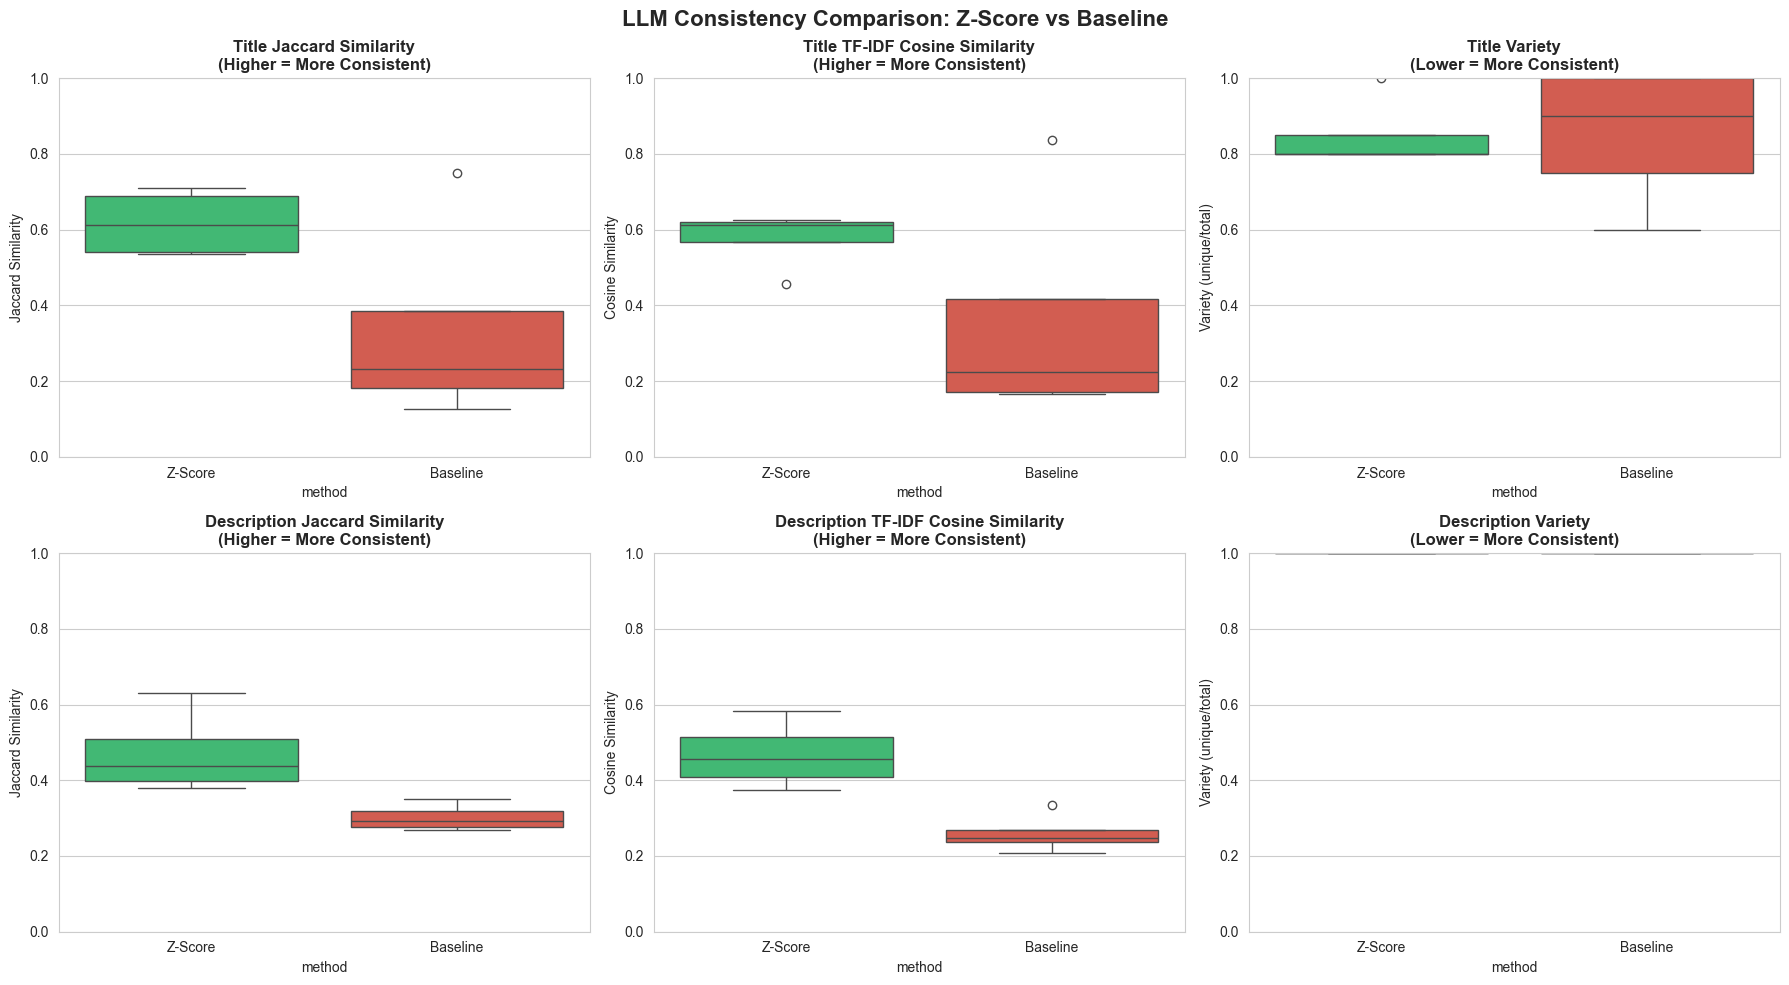


✓ Visualization complete!


In [7]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('LLM Consistency Comparison: Z-Score vs Baseline', fontsize=16, fontweight='bold')

# Prepare data for plotting
consistency_zscore['method'] = 'Z-Score'
consistency_baseline['method'] = 'Baseline'
combined_df = pd.concat([consistency_zscore, consistency_baseline], ignore_index=True)

# Plot 1: Title Jaccard Similarity
ax = axes[0, 0]
sns.boxplot(data=combined_df, x='method', y='title_jaccard', ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title('Title Jaccard Similarity\n(Higher = More Consistent)', fontweight='bold')
ax.set_ylabel('Jaccard Similarity')
ax.set_ylim([0, 1])

# Plot 2: Title TF-IDF Cosine
ax = axes[0, 1]
sns.boxplot(data=combined_df, x='method', y='title_tfidf_cosine', ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title('Title TF-IDF Cosine Similarity\n(Higher = More Consistent)', fontweight='bold')
ax.set_ylabel('Cosine Similarity')
ax.set_ylim([0, 1])

# Plot 3: Title Variety
ax = axes[0, 2]
sns.boxplot(data=combined_df, x='method', y='title_variety', ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title('Title Variety\n(Lower = More Consistent)', fontweight='bold')
ax.set_ylabel('Variety (unique/total)')
ax.set_ylim([0, 1])

# Plot 4: Description Jaccard Similarity
ax = axes[1, 0]
sns.boxplot(data=combined_df, x='method', y='desc_jaccard', ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title('Description Jaccard Similarity\n(Higher = More Consistent)', fontweight='bold')
ax.set_ylabel('Jaccard Similarity')
ax.set_ylim([0, 1])

# Plot 5: Description TF-IDF Cosine
ax = axes[1, 1]
sns.boxplot(data=combined_df, x='method', y='desc_tfidf_cosine', ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title('Description TF-IDF Cosine Similarity\n(Higher = More Consistent)', fontweight='bold')
ax.set_ylabel('Cosine Similarity')
ax.set_ylim([0, 1])

# Plot 6: Description Variety
ax = axes[1, 2]
sns.boxplot(data=combined_df, x='method', y='desc_variety', ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_title('Description Variety\n(Lower = More Consistent)', fontweight='bold')
ax.set_ylabel('Variety (unique/total)')
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")

## 7. Per-Cluster Consistency Heatmap

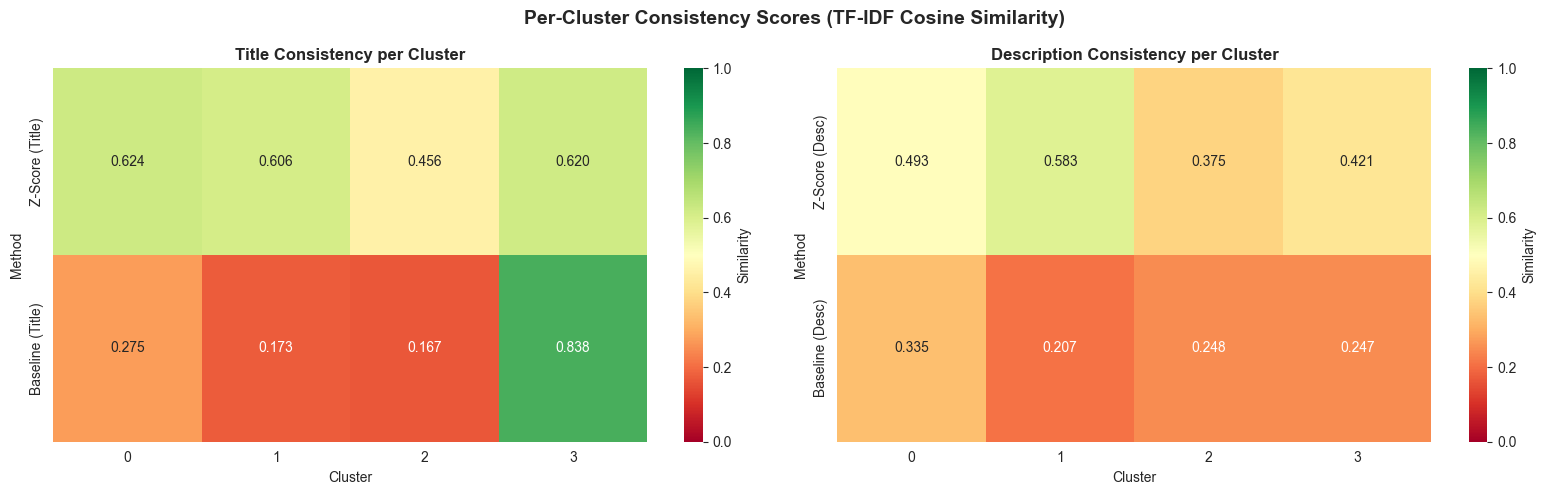


✓ Heatmap visualization complete!


In [8]:
# Create heatmap comparing consistency per cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Per-Cluster Consistency Scores (TF-IDF Cosine Similarity)', fontsize=14, fontweight='bold')

# Prepare data
cluster_comparison = pd.DataFrame({
    'Cluster': consistency_zscore['cluster_id'],
    'Z-Score (Title)': consistency_zscore['title_tfidf_cosine'],
    'Z-Score (Desc)': consistency_zscore['desc_tfidf_cosine'],
    'Baseline (Title)': consistency_baseline['title_tfidf_cosine'],
    'Baseline (Desc)': consistency_baseline['desc_tfidf_cosine']
})

# Heatmap 1: Title consistency
ax = axes[0]
title_data = cluster_comparison[['Cluster', 'Z-Score (Title)', 'Baseline (Title)']].set_index('Cluster').T
sns.heatmap(title_data, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, 
            ax=ax, cbar_kws={'label': 'Similarity'})
ax.set_title('Title Consistency per Cluster', fontweight='bold')
ax.set_ylabel('Method')

# Heatmap 2: Description consistency
ax = axes[1]
desc_data = cluster_comparison[['Cluster', 'Z-Score (Desc)', 'Baseline (Desc)']].set_index('Cluster').T
sns.heatmap(desc_data, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, 
            ax=ax, cbar_kws={'label': 'Similarity'})
ax.set_title('Description Consistency per Cluster', fontweight='bold')
ax.set_ylabel('Method')

plt.tight_layout()
plt.show()

print("\n✓ Heatmap visualization complete!")

## 8. Final Summary and Conclusion

In [ ]:
print("\n" + "="*80)
print(" FINAL SUMMARY: LLM CONSISTENCY ANALYSIS")
print("="*80)

# Create summary tables
print("\n📊 TABLE 1: CONSISTENCY SCORES COMPARISON (Mean across all clusters)")
print("="*80)
print("Higher scores = More consistent LLM outputs\n")

# Title consistency table
title_comparison = pd.DataFrame({
    'Metric': ['Jaccard Similarity', 'TF-IDF Cosine', 'Levenshtein'],
    'Z-Score': [
        stats_zscore['title_jaccard_mean'],
        stats_zscore['title_tfidf_cosine_mean'],
        stats_zscore['title_levenshtein_mean']
    ],
    'Baseline': [
        stats_baseline['title_jaccard_mean'],
        stats_baseline['title_tfidf_cosine_mean'],
        stats_baseline['title_levenshtein_mean']
    ]
})
title_comparison['Improvement'] = title_comparison['Z-Score'] - title_comparison['Baseline']
title_comparison['% Better'] = ((title_comparison['Z-Score'] / title_comparison['Baseline']) - 1) * 100

print("TITLE CONSISTENCY:")
print(title_comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Description consistency table
desc_comparison = pd.DataFrame({
    'Metric': ['Jaccard Similarity', 'TF-IDF Cosine', 'Levenshtein'],
    'Z-Score': [
        stats_zscore['desc_jaccard_mean'],
        stats_zscore['desc_tfidf_cosine_mean'],
        stats_zscore['desc_levenshtein_mean']
    ],
    'Baseline': [
        stats_baseline['desc_jaccard_mean'],
        stats_baseline['desc_tfidf_cosine_mean'],
        stats_baseline['desc_levenshtein_mean']
    ]
})
desc_comparison['Improvement'] = desc_comparison['Z-Score'] - desc_comparison['Baseline']
desc_comparison['% Better'] = ((desc_comparison['Z-Score'] / desc_comparison['Baseline']) - 1) * 100

print("\n\nDESCRIPTION CONSISTENCY:")
print(desc_comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Variety/Diversity table
variety_comparison = pd.DataFrame({
    'Content Type': ['Title', 'Description'],
    'Z-Score': [
        stats_zscore['title_variety_mean'],
        stats_zscore['desc_variety_mean']
    ],
    'Baseline': [
        stats_baseline['title_variety_mean'],
        stats_baseline['desc_variety_mean']
    ]
})
variety_comparison['Reduction'] = variety_comparison['Baseline'] - variety_comparison['Z-Score']
variety_comparison['% Less Varied'] = ((variety_comparison['Baseline'] - variety_comparison['Z-Score']) / variety_comparison['Baseline']) * 100

print("\n\nVARIETY/DIVERSITY (Lower = More Consistent):")
print(variety_comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Statistical significance table
print("\n\n📈 TABLE 2: STATISTICAL SIGNIFICANCE TESTS")
print("="*80)
sig_table = significance_results[['metric', 'zscore_mean', 'baseline_mean', 'difference', 'p_value', 'cohens_d', 'winner']].copy()
sig_table.columns = ['Metric', 'Z-Score', 'Baseline', 'Difference', 'p-value', "Cohen's d", 'Winner']
sig_table['Significant'] = sig_table['p-value'].apply(lambda x: '✓' if x < 0.05 else '✗')

print(sig_table.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

sig_count = len(significance_results[significance_results['p_value'] < 0.05])
print(f"\n↳ {sig_count}/{len(significance_results)} metrics show significant differences (p < 0.05)")

# Conclusion
print("\n\n🎯 TABLE 3: CONCLUSION")
print("="*80)

zscore_wins = len(significance_results[(significance_results['winner'] == 'Z-Score') & 
                                       (significance_results['p_value'] < 0.05)])
baseline_wins = len(significance_results[(significance_results['winner'] == 'Baseline') & 
                                         (significance_results['p_value'] < 0.05)])

conclusion_data = pd.DataFrame({
    'Category': ['Significant Wins', 'Effect Size (Mean)', 'Overall Verdict'],
    'Z-Score': [
        zscore_wins,
        significance_results[significance_results['winner'] == 'Z-Score']['cohens_d'].mean(),
        'WINNER ✓' if zscore_wins > baseline_wins else ('LOSER ✗' if zscore_wins < baseline_wins else 'TIE')
    ],
    'Baseline': [
        baseline_wins,
        significance_results[significance_results['winner'] == 'Baseline']['cohens_d'].abs().mean(),
        'LOSER ✗' if zscore_wins > baseline_wins else ('WINNER ✓' if zscore_wins < baseline_wins else 'TIE')
    ]
})

print(conclusion_data.to_string(index=False))

if zscore_wins > baseline_wins:
    print("\n✓ HYPOTHESIS CONFIRMED:")
    print("  Z-Score ranking produces significantly more consistent LLM outputs")
    print("  compared to baseline statistics across multiple runs.")
elif baseline_wins > zscore_wins:
    print("\n✗ HYPOTHESIS REJECTED:")
    print("  Baseline statistics produces more consistent LLM outputs")
    print("  compared to z-score ranking.")
else:
    print("\n⚠ INCONCLUSIVE:")
    print("  No clear winner - both methods show similar consistency.")

print("\n" + "="*80)


 FINAL SUMMARY: LLM CONSISTENCY ANALYSIS

📊 OVERALL CONSISTENCY SCORES (Mean across all clusters):
--------------------------------------------------------------------------------

1. TITLE CONSISTENCY:
   Z-Score Jaccard:      0.6175
   Baseline Jaccard:     0.3346
   Improvement:          +0.2829
   % Better:             +84.6%

   Z-Score TF-IDF:       0.5764
   Baseline TF-IDF:      0.3631
   Improvement:          +0.2133
   % Better:             +58.7%

2. DESCRIPTION CONSISTENCY:
   Z-Score Jaccard:      0.4713
   Baseline Jaccard:     0.3014
   Improvement:          +0.1699
   % Better:             +56.4%

   Z-Score TF-IDF:       0.4680
   Baseline TF-IDF:      0.2592
   Improvement:          +0.2088
   % Better:             +80.5%

3. VARIETY/DIVERSITY (Lower is better):
   Z-Score Title:        0.8500
   Baseline Title:       0.8500
   Reduction:            -0.0000

   Z-Score Description:  1.0000
   Baseline Description: 1.0000
   Reduction:            +0.0000

------------

## 9. Export Results

In [10]:
import os
from datetime import datetime

# Create output directory
output_dir = r'C:\Users\weezh\OneDrive\Desktop\pyhercules\evaluation\Consistency Test (specific cluster accross run)'
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save detailed consistency metrics
consistency_zscore['method'] = 'Z-Score'
consistency_baseline['method'] = 'Baseline'
combined_consistency = pd.concat([consistency_zscore, consistency_baseline], ignore_index=True)

consistency_path = os.path.join(output_dir, f'consistency_metrics_detailed_{timestamp}.csv')
combined_consistency.to_csv(consistency_path, index=False)
print(f"✓ Saved detailed metrics: {os.path.basename(consistency_path)}")

# Save aggregate comparison
comparison_path = os.path.join(output_dir, f'consistency_comparison_aggregate_{timestamp}.csv')
comparison_df.to_csv(comparison_path, index=False)
print(f"✓ Saved aggregate comparison: {os.path.basename(comparison_path)}")

# Save statistical significance results
significance_path = os.path.join(output_dir, f'consistency_statistical_tests_{timestamp}.csv')
significance_results.to_csv(significance_path, index=False)
print(f"✓ Saved statistical tests: {os.path.basename(significance_path)}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE - All results saved!")
print("="*80)

✓ Saved detailed metrics: consistency_metrics_detailed_20260310_181435.csv
✓ Saved aggregate comparison: consistency_comparison_aggregate_20260310_181435.csv
✓ Saved statistical tests: consistency_statistical_tests_20260310_181435.csv

ANALYSIS COMPLETE - All results saved!
